In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.colors as mc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import matplotlib.font_manager as fm
import numpy as np 
import seaborn as sns 
import math
import folium
import ipywidgets as widgets

import requests
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
from shapely.ops import unary_union
from shapely.geometry import shape, mapping
from shapely.ops import nearest_points
from pyproj import Geod
import plotly.colors as pc
import colorsys


# 1. Motivation

### What is your dataset?

In this project, we take a closer look at the United Nations Refugee Agency (UNHCR) dataset on forced displacement flows. This dataset is a comprehensive list that records international displacements from 1962 to 2025, where each entry has a country of "Origin", an "Arrival" country, and a number of people. We have over 100.000 entries to work with.
You can find the dataset here:
https://www.unhcr.org/refugee-statistics/insights/explainers/forcibly-displaced-flow-data.html

In our dataset, four different status types are recorded:

- **Asylum seekers (ASY):** people who have applied for asylum and are waiting for a decision on their application

- **Refugees (REF):** People who have been forced to flee their country because of persecution, war, or violence and have been recognized as refugees by the UNHCR. More precisely "defined by the 1951 Geneva Convention, any person who, owing to a well‐founded fear of persecution for reasons of race, religion, nationality, membership of a particular social group or political opinion, is outside the country of his or her nationality...and is  unable or, owing to such fear, is unwilling to return to it”. (ref: https://www.unesco.org/en/articles/migrants-refugees-or-displaced-persons)

- **Other people in need of international protection” (OIP):** defined by the UNHCR as “people who are outside their country or territory of origin, typically because they have been forcibly displaced across international borders, who have not been reported under other categories (asylum-seekers, refugees, people in refugee-like situations) but who likely need international protection. (ref: https://data.unicef.org/topic/child-migration-and-displacement/displacement/)

- **Refugees and others of concern":** A status that is less universally standardized, but in migration/displacement databases it often refered.

### Why did you choose this particular dataset?

We wanted to do something different and look into something we are passionate about (we personally know people with refugee status), and we think it's a really interesting and relevant dataset given how much of a political hot topic refugees and asylum seekers have been in recent decades.

### What was your goal for the end user's experience?

The goal is to make user feel like they have a better understanding of the global situation with displaced people. Where most of them come from, what their situation is like, and why they choose to go where they go.

# 2. Basic Stats

## 2.1 Data Cleaning and Preprocessing

In [ ]:
# load excel dataset
raw_data = pd.read_excel(
    'Data/UNHCR_Flow_Data.xlsx',
    sheet_name='DATA'
)

First, we're going to cover the basics: standardize the data to lowercase, remove duplicates, and remove rows with missing values. There really isn't that much cleaning to do, since it's a very well-maintained dataset and the kind folks at the UNHCR have already covered most of their bases.

In [ ]:
# -------------------------------------------------------------------
#                      changes to the raw data
# -------------------------------------------------------------------

# header to lowercase
raw_data.columns = raw_data.columns.str.lower()
# data to lowercase
for col in raw_data.select_dtypes(include='str'):
    raw_data[col] = raw_data[col].str.lower()

# remove duplicates
raw_data = raw_data.drop_duplicates()

# remove rows with missing values
raw_data = raw_data.dropna()


Next, we have some very long formal country names in the dataset, fx. Syria is called the "Syrian Arab Republic", and Venezuela is called "Venezuela (Bolivarian Republic of)". You can find the full list in the code below.

In [ ]:
# ---------------------------------------------------------
#         Dealing with long impractical country names
# ---------------------------------------------------------

# change "originname"
name_edits = {
    "serbia and kosovo: s/res/1244 (1999)": "serbia/kosovo",
    "bolivia (plurinational state of)": "bolivia",
    "iran (islamic rep. of)": "iran",
    "netherlands (kingdom of the)": "nederland",
    "côte d'ivoire": "ivory coast",
    "state of palestine": "palestine",
    "lao people's dem. rep": "laos",
    "russian federation": "russia",
    "syrian arab rep.": "syria",
    "dem. rep. of the congo": "dr congo",
    "congo, republic of": "congo",
    "china, hong kong sar": "hong kong",
    "rep. of korea": "south korea",
    "dem. people's rep. of korea": "north korea",
    "central african rep.": "central african republic",
    "dominican rep.": "dominican republic",
    "united rep. of tanzania": "tanzania",
    "venezuela (bolivarian republic of)": "venezuela",
    "rep. of moldova": "moldova"
}

#            Apply changes
# -----------------------------------
# country name changes to the 'originname' column
raw_data['originname'] = raw_data['originname'].replace(name_edits)
raw_data["asylumname"] = raw_data["asylumname"].replace(name_edits)


Finally, we're going to filter the data. The dataset contains over 100,000 entries, but 76,000 of the entries are tiny flows with less than 100 people. Filtering them out gives us a leaner, less noisy dataset, while preserving almost all of the raw numbers.

In [ ]:
# Count rows that have 'count' less than 100
less_than_100 = raw_data[raw_data['count'] < 100].shape[0]
print(f"Number of rows with 'count' less than 100: {less_than_100}")
# filter out rows where 'count' is less than 100
filtered_data = raw_data[raw_data['count'] >= 100].copy()


In [ ]:
# export cleaned data to csv
clean_data = raw_data
clean_data.to_csv('Data/cleaned_data.csv', index=False)

# export filtered data to csv
filtered_data.to_csv('Data/filtered_data.csv', index=False)

### 1.2 Data Exploration

To get an overview of the fundamental distribution of our dataset, we're going to take a look at how many entries we have per year.

In [ ]:
# ---------------------------------------------------------------
#                           data count
# ---------------------------------------------------------------

# count number of entries per year for the cleaned data
num_entries_per_year_clean = clean_data['year'].value_counts().sort_index()
# print(num_entries_per_year_clean)

# count number of entries per year for filtered data
num_entries_per_year_filtered = filtered_data['year'].value_counts().sort_index()
# print(num_entries_per_year_filtered)

# common y-axis limit
max_count = max(
    num_entries_per_year_clean.max(),
    num_entries_per_year_filtered.max()
)

# plot the two histograms side by side
# -------------------------------------
plt.figure(figsize=(12, 5))

#           cleaned data
# -------------------------------------
plt.subplot(1, 2, 1)
plt.hist(
    clean_data['year'],
    bins=np.arange(
        clean_data['year'].min(),
        clean_data['year'].max() + 2
    ) - 0.5,
    color='darkcyan',
    alpha=0.6,
    edgecolor='lightgray',
    linewidth=0.5
)

plt.title('Number of Entries per Year (Cleaned Data)', pad=15, fontsize=12)
plt.xlabel('Year', labelpad=10)
plt.ylabel('Number of Entries', labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, max_count + 300)
plt.margins(y=0.05)
plt.grid(axis='x', alpha=0.2)
plt.grid(axis='y', alpha=0.2)


#           filtered data
# -------------------------------------
plt.subplot(1, 2, 2)
plt.hist(
    filtered_data['year'],
    bins=np.arange(
        filtered_data['year'].min(),
        filtered_data['year'].max() + 2
    ) - 0.5,
    color='orange',
    edgecolor='lightgray',
    linewidth=0.5
)

plt.title('Number of Entries per Year (Filtered Data)', pad=15, fontsize=12)
plt.xlabel('Year', labelpad=10)
plt.ylabel('Number of Entries', labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, max_count + 300)
plt.margins(y=0.05)
plt.grid(axis='x', alpha=0.2)
plt.grid(axis='y', alpha=0.2)

# change opacity of the frame
for ax in plt.gcf().axes:
    for spine in ax.spines.values():
        spine.set_edgecolor((0, 0, 0, 0.2))  # 20% opacity
        spine.set_linewidth(0.2)

plt.tight_layout()

plt.show()



From our histograms, we immediately notice an increase in number of entries over time spanning from 10 entries in 1962, to the peak of over 4.500 displacements recorded for 2023. This could be due to several factors:
- An increase in sheer data collection over time, particularly after the year 2000, where we notice a sudden rise in numbers of entries
- More international movements in recent years? as opposed to internal displacements, which the dataset would not show.
- We are more people on the planet than we were in 1960 (3 billion in total in 1960 VS over 8 billion today) more people statistically means more total displacements.

We see that in general, we have way more data for recent decades than for earlier decades. The filtered dataset makes the contrast a little less jarring. Here's a closer look at entries between 1962 and 1981, since some of those values are relatively low.

In [ ]:
# first 10 years
clean_first_20 = num_entries_per_year_clean.head(20)
filtered_first_20 = num_entries_per_year_filtered.head(20)

# create comparison table
comparison_table = pd.DataFrame({
    'Cleaned Data': clean_first_20,
    'Filtered Data': filtered_first_20
}).T

print(comparison_table)

Now we've looked at the number of entries, but let's also look at the raw numbers, to verify that we haven't too eagerly thrown away a bunch of data with our filtering. We did remove around 75% of the entries, so it's important that it doesn't change the picture too much. We're going to plot the raw counts of displaced people for both the cleaned data, and the filtered data.

In [ ]:
# -----------------------------------------
#           Displacements per year
# -----------------------------------------

# quick reminder:
# number of entries in each dataset
# ------------------------

# number of entries in clean_data
num_clean = clean_data.shape[0]
print("number of entries in clean_data:", num_clean)

# number of entries in filtered_data
num_filtered = filtered_data.shape[0]
print("number of entries in filtered_data:", num_filtered)
print()

#     Displacement count per year
# -------------------------------------

# with clean data
clean_data['count'] = pd.to_numeric(clean_data['count'], errors='coerce')
refugees_per_year = clean_data.groupby('year')['count'].sum().reset_index()
refugees_per_year = refugees_per_year.sort_values('year')

# with filtered data
filtered_data['count'] = pd.to_numeric(filtered_data['count'], errors='coerce')
refugees_per_year_filtered = filtered_data.groupby('year')['count'].sum().reset_index()
refugees_per_year_filtered = refugees_per_year_filtered.sort_values('year')

# compare
# ------------------
comparison_table = pd.DataFrame({
    'clean_data': refugees_per_year.set_index('year')['count'],
    'filtered_data': refugees_per_year_filtered.set_index('year')['count']
}).T

display(comparison_table.style.format("{:,.0f}"))

# Plotting the two
# ------------------

# Plotting the two side by side
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Cleaned Data plot
axes[0].plot(
    refugees_per_year["year"],
    refugees_per_year["count"],
    color='darkcyan',
    alpha=0.9
)
axes[0].set_xlabel("Year", fontsize=12, labelpad=10)
axes[0].set_ylabel("Forced displacement count")
axes[0].set_title("Total displacements per year (Cleaned Data)")
axes[0].grid(True, alpha=0.3)

# frame opacity
for spine in axes[0].spines.values():
    spine.set_alpha(0.2)

# Filtered Data plot
axes[1].plot(
    refugees_per_year_filtered["year"],
    refugees_per_year_filtered["count"],
    color='darkorange',
    alpha=0.9
)
axes[1].set_xlabel("Year", fontsize=12, labelpad=10)
axes[1].set_title("Total displacements per year (Filtered Data)")
axes[1].grid(True, alpha=0.3)

# frame opacity
for spine in axes[1].spines.values():
    spine.set_alpha(0.2)

plt.tight_layout()
plt.show()



As we can clearly see, the two graphs are almost identical. Seeing as removing 75% of the small entries makes such a minor difference in displacements counts, we will continue this project with the smaller "filtered data" and it's 30405 entries that represent the great majority of our data.

How many total countries are mentioned in this dataset? When are they first mentionned?
Can we see some new counrty names appearing over time? for example:
- Croatia, Estonia, Slovenia, Kazakhstan, Azerbaijan in the early 90's?
- Eritrea in 1993?
- Montenegro/Serbia 2006?
- South Sudan in 2011?

Are there countries that only "recieve" asylum seekers?

Are there countries that only "send" asylunm seekers?

In [ ]:
# total names and year
unique_origin_countries = clean_data['originname'].unique()
print("Total unique origin countries:", len(unique_origin_countries))

# total name and year
unique_destination_countries = clean_data['asylumname'].unique()
print("Total unique destination countries:", len(unique_destination_countries))

unique_countries = set(unique_origin_countries).union(set(unique_destination_countries))
print("Total unique countries (origin + destination):", len(unique_countries))

# find the 3 countries that are only in the destination column and not in the origin column
only_destination_countries = set(unique_destination_countries) - set(unique_origin_countries)
print("Countries that are only in the destination column:", only_destination_countries)

# 3 Data analysis


### 3.1 Identifying "crisis episodes"

An important part of the picture when looking at forced displacement is that usually, large waves of forcibly displaced people are caused by geopolitical crises such as war or persecution. Natural disasters are also a big cause globally, but these crises don't usually force people to leave their country, so such displacements are not part of our dataset. Instead of going in with biases about which conflicts we think are relevant, we're going to try to let the data speak for itself by extracting the "crisis episodes" directly from the data using consistent methodology.

Here is what we took into consideration:
-  Conflicts/crises vary greatly in length for example the Rwanda Genocide (about half a year), the Syrian Civil War (over 15 years). One million people moving in one year will not have the same effect as one million people moving over the course of 15 years. So we decided to track "crises" based on sudden increases in displacements in our data.
- We define a crisis episode as a period of consecutive years where a country has total outgoing flows of displaced people above its median value, and above a minimum threshold of 10,000 per year. We also set a maximum threshold of 100,000 so we don't chop episodes in half for countries with anomalously high medians (specifically Afghanistan gave us a lot of trouble with this, as the median for all recorded years is over 136,000!).

In [ ]:
# -------------------------------------------------
#            Finding the largest crises
# -------------------------------------------------
# episode-based conflict significance analysis (variable-length conflicts)

#    parameters
# -----------------
min_activation = 10000         # minimum yearly displaced people to consider a year "active"
max_activation = 100000        # maximum threshold to handle anomalies like Afghanistan
activation_multiplier = 1.0     # origin-specific threshold = baseline * multiplier
quiet_years_to_end = 1          # end episode after this many consecutive below-threshold years

# sum across all asylum countries
# ------------------------------------
origin_yearly = (
    filtered_data.groupby(['origin', 'originname', 'year'], as_index=False)['count']
    .sum()
)

# ------------------------------------
#     Search for crisis in data  
# ------------------------------------
# runs separately for each origin country
def detect_origin_episodes(group):
    series = group.set_index('year')['count'].sort_index()
    full_years = range(int(series.index.min()), int(series.index.max()) + 1)
    series = series.reindex(full_years, fill_value=0)

    #    "crisis" threshold
    # --------------------------
    positive = series[series > 0]
    # median-based threshold for detecting the episode  
    baseline = float(positive.median()) if not positive.empty else 0.0 #
    # final threshold is the max between median-based and 10,000, capped at 100,000
    threshold = min( max(min_activation, baseline * activation_multiplier), max_activation)

    # store detected episodes
    episodes = [] #
    in_episode = False 
    start_year = None
    low_streak = 0 # set to 0 when in episode, counts consecutive years below threshold

    #    scan year by year
    # --------------------------
    for year, value in series.items():
        # add new episode
        if not in_episode and value >= threshold:
            in_episode = True
            start_year = int(year)
            low_streak = 0
            continue
        #  update status of existing episode
        if in_episode:
            # if value falls below threshold, count it as a "low year"
            if value < threshold:
                low_streak += 1
                if low_streak >= quiet_years_to_end:
                    end_year = int(year) - quiet_years_to_end
                    if end_year >= start_year:
                        episodes.append((start_year, end_year, threshold))
                    in_episode = False
                    start_year = None
                    low_streak = 0
            # if the value is above threshold continue
            else:
                low_streak = 0

    # acontinue an episode that is still active
    if in_episode and start_year is not None:
        episodes.append((start_year, int(series.index.max()), threshold))

    # store episode details for this origin country
    rows = []

    # compute episode metrics
    # --------------------------
    for episode_num, (start, end, threshold_used) in enumerate(episodes, start=1):
        episode_series = series.loc[start:end]
        total_displaced = float(episode_series.sum())
        peak_annual = float(episode_series.max())
        duration_years = int(end - start + 1)
        mean_annual = float(total_displaced / duration_years)
        ramp_up = float(episode_series.diff().fillna(0).max())

        rows.append({
            'origin': group['origin'].iloc[0],
            'originname': group['originname'].iloc[0],
            'episode': episode_num, #refers to the number of forced displacements detected in that origin country
            'start_year': start,
            'end_year': end,
            'duration_years': duration_years,
            'threshold_used': float(threshold_used), # median-based threshold for detecting the episode
            'total_displaced': total_displaced,
            'peak_annual': peak_annual,
            'mean_annual': mean_annual,
            'ramp_up': ramp_up, # how quickly the episode escalated in its first year (max year-over-year increase)
        })

    # returns metrics for all episodes detected in that origin country
    return rows

#  run episode detection 
# for each origin country
# --------------------------
episode_rows = []
for _, g in origin_yearly.groupby(['origin', 'originname']):
    episode_rows.extend(detect_origin_episodes(g))
# create dataframe 
episodes_df = pd.DataFrame(episode_rows)

# rank episodes
# ----------------
# ranked by total displaced in the whole duration of the episode
top_by_total = episodes_df.sort_values('total_displaced', ascending=False).reset_index(drop=True)
print('Top episodes by total displaced:')
display(top_by_total.head(20))


The results line up pretty well with our expectations, and all of them seem to relate to recognizable real-world crises. The timeframes aren't all exactly right (Aghanistan is again a notable outlier, but for good reasons), but they're pretty close, and refugee flows don't necessarily correlate 1-to-1 with the beginning and end of a conflict.

Something that bears mentioning is "unknown/other" being #14 on our list, with a detected crisis timeframe from 1980-1995. We theorize that the spike in refugees with unknown origin could be related to the breakup of Yugoslavia and/or the fall of the USSR, but it's hard to be sure.

### GeoJSON, ISO codes and How far do people go on average? 

With GeoJSON, we can compute the distance between countries. 
We initially computed the distance "centroid to centroid" and then considered "centroid to next_border" to get a better estimation. Refugees don't need to reach the center of their host countries before seeking Asylum, they only need to reach the border.

Note. our estimation offers a rather crude estimation and gives an average "as bird flies" from one country to another. It does not take into consideration actual travel distances, routes, border crossings, or internal displacement before/after crossing

In [ ]:
# -----------------------------------------------------------------------------------------------------
#                               compute the distances between countries
# -----------------------------------------------------------------------------------------------------

# ----------------------------------
#        Centroid to Centroid
# ----------------------------------

geod = Geod(ellps="WGS84")

def country_distance_km(origin_iso, asylum_iso):
    o = country_coords.get(str(origin_iso).upper())
    a = country_coords.get(str(asylum_iso).upper())

    if o is None or a is None:
        return np.nan

    _, _, distance_m = geod.inv(
        o[1], o[0],   # origin lon, lat
        a[1], a[0],   # destination lon, lat
    )

    return round((distance_m / 1000), 2)

# test 
print("centroid to centroid:")
print("distance between centroid Afghanistan and centroid of Iran:", country_distance_km("afg", "irn"))
print("distance between centroid Australia and centroid of Brazil:", country_distance_km("aus", "bra"))
print("distance between centroid France and centroid of Germany:", country_distance_km("fra", "deu"))

# ----------------------------------
#     Centroid to next border
# ----------------------------------

# load country geometries
countries_gdf = gpd.read_file(
    "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
)

# compute distance from origin country centroid to nearest point on border of destination country
# compute distance from origin country centroid
# to nearest point on border of destination country
def distance_to_country_border_km(origin_iso, border_iso, countries_gdf):

    origin_match = countries_gdf.loc[
        countries_gdf["id"].str.upper() == str(origin_iso).upper(),
        "geometry"
    ]

    border_match = countries_gdf.loc[
        countries_gdf["id"].str.upper() == str(border_iso).upper(),
        "geometry"
    ]

    # handle missing ISO codes
    if origin_match.empty or border_match.empty:
        return np.nan

    origin_geom = origin_match.iloc[0]
    border_geom = border_match.iloc[0]

    origin_point = origin_geom.representative_point()

    border_line = border_geom.boundary

    nearest_origin_point, nearest_border_point = nearest_points(
        origin_point,
        border_line
    )

    _, _, distance_m = geod.inv(
        nearest_origin_point.x,
        nearest_origin_point.y,
        nearest_border_point.x,
        nearest_border_point.y,
    )

    return round((distance_m / 1000), 2)

print()
print("centroid to border distances:")
print("distance between central Afghanistan and the border if Iran:", distance_to_country_border_km("afg", "irn", countries_gdf)) 
print("distance between central Australia and the border of Brazil:", distance_to_country_border_km("aus", "bra", countries_gdf))  
print("distance between central France and the border of Germany:", distance_to_country_border_km("fra", "deu", countries_gdf))

In [ ]:
# -------------------------------------------------------------
#              missing ISO codes in GeoJSON
# -------------------------------------------------------------

available_isos = set(countries_gdf["id"].str.upper())

# ISO codes used in flow data
origin_isos = set(flow_df["originiso"].dropna().str.upper())
asylum_isos = set(flow_df["asylumiso"].dropna().str.upper())

# missing origin ISO codes
missing_origin = sorted(origin_isos - available_isos)

# missing asylum ISO codes
missing_asylum = sorted(asylum_isos - available_isos)

print("Missing origin ISO codes:")
print(missing_origin)

print()
print("Missing asylum ISO codes:")
print(missing_asylum)

#       how many rows are affected
# ------------------------------------------
missing_origin_rows = flow_df[
    ~flow_df["originiso"].str.upper().isin(available_isos)
]

missing_asylum_rows = flow_df[
    ~flow_df["asylumiso"].str.upper().isin(available_isos)
]

print("Rows with missing origin ISO:", len(missing_origin_rows))
print("Rows with missing asylum ISO:", len(missing_asylum_rows))
print()

#     how many refugees that is in total
# -----------------------------------------
total_missing_origin = missing_origin_rows['count'].sum()
total_missing_asylum = missing_asylum_rows['count'].sum()
print(f"Total refugees with missing origin ISO: {total_missing_origin:,}")
print(f"Total refugees with missing asylum ISO: {total_missing_asylum:,}")
print()


#       full names of missing ISO codes
# -----------------------------------------
import pycountry

print("Missing origin ISO country names:")
for iso in missing_origin:
    country = pycountry.countries.get(alpha_3=iso)
    if country is not None:
        print(f"{iso}: {country.name}")
    else:
        print(f"{iso}: Unknown")

print()

print("Missing asylum ISO country names:")
for iso in missing_asylum:
    country = pycountry.countries.get(alpha_3=iso)
    if country is not None:
        print(f"{iso}: {country.name}")
    else:
        print(f"{iso}: Unknown")

# count how many refugeed that is per year
# -----------------------------------------
#   Combined missing ISO refugee counts per year
# -----------------------------------------------

all_missing_rows = flow_df[
    (
        ~flow_df["originiso"].str.upper().isin(available_isos)
    )
    |
    (
        ~flow_df["asylumiso"].str.upper().isin(available_isos)
    )
]

missing_iso_comparison = pd.DataFrame({
    'num_displaced<br>_people_unmapped': (
        all_missing_rows
        .groupby('year')['count']
        .sum()
    )
}).T

display(missing_iso_comparison.style.format("{:,.0f}"))



# 4. Genre

# 5. Visualizations

The first visualization is going to be a big-picture overview: all of the data for the whole period in one huge interactive map. Countries with outgoing flows of displaced people will be colored with a white-red gradient, and purple arrows will show which countries people are fleeing to.

In [ ]:
# -------------------------------
#       prepping for mapping
# -------------------------------

resp = requests.get("https://restcountries.com/v3.1/all?fields=cca3,latlng")
country_coords = {}
for c in resp.json():
    iso3 = c.get("cca3", "")
    latlng = c.get("latlng", [])
    if iso3 and len(latlng) == 2:
        country_coords[iso3] = (float(latlng[0]), float(latlng[1]))  # (lat, lon)

print(f"Loaded centroids for {len(country_coords)} countries")
print(f"Sample keys: {list(country_coords.keys())[:6]}")

# Use filtered_data (lowercase columns)
all_iso = set(filtered_data['originiso'].dropna().str.upper()) | set(filtered_data['asylumiso'].dropna().str.upper())
matched = all_iso & set(country_coords.keys())
missing = all_iso - set(country_coords.keys())
print(f"ISO codes in dataset: {len(all_iso)}, matched: {len(matched)}, missing: {len(missing)}")
print(f"Missing sample: {list(missing)[:10]}")

In [ ]:
# ----------------------------------------------------------------------------
#                                    MAP 1
# ----------------------------------------------------------------------------

flow_df = (
    filtered_data.groupby(['year', 'originiso', 'asylumiso'], as_index=False)['count'].sum()
)
TOP_N = 100
# apply filter
top_flows = (
    flow_df.sort_values('count', ascending=False)
    .groupby('year', group_keys=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
# count total displaced people per origin country and year
origin_year = (
    filtered_data.groupby(['year', 'originiso', 'originname'], as_index=False)['count'].sum()
)

# Count number of unique destination countries reached by each origin country per year
dest_counts = (
    filtered_data.groupby(['year', 'originiso'])['asylumiso']
    .nunique()
    .reset_index(name='n_dest')
)
# Merge displacement totals with destination counts
origin_enriched = origin_year.merge(dest_counts, on=['year', 'originiso'], how='left')
# Replace missing values and convert to integer
origin_enriched['n_dest'] = origin_enriched['n_dest'].fillna(0).astype(int)

# Animation + visualisation settings
# -----------------------------------
# List of years used for animation frames
years_list = sorted(origin_enriched['year'].unique())
# Number of line-width buckets for flows
N_BUCKETS  = 5
# Total number of traces: 1 choropleth + flow buckets + arrow buckets
N_TRACES   = 1 + N_BUCKETS + N_BUCKETS + 1

# Fix colour scale maximum to 1 million so colours remain consistent across years
global_max_c = 1_000_000
# Log-scaled upper bound
log_max = float(np.log1p(global_max_c))
# Minimum threshold for colour intensity, values below 1k appear very light
log_min = float(np.log1p(100))
# Maximum flow size used for line scaling
global_max_f = float(np.log1p(top_flows['count'].max())) if not top_flows.empty else 1.0
global_log_max_f = float(global_max_f if global_max_f > 0 else 1.0)

_tick_raw  = [100, 1_000, 10_000, 100_000, 1_000_000]
# Convert tick values to logarithmic scale
_tick_vals = [float(np.log1p(v)) for v in _tick_raw if v <= global_max_c]
# Labels shown on colourbar
_tick_text = ["100", "1k", "10k", "100k", "1M"][:len(_tick_vals)]

# hex → rgba
def hex_to_rgba(hex_color, alpha):
    r, g, b = mcolors.to_rgb(hex_color)
    return f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, {alpha})"

# flow ratio → rgba
def flow_color_from_ratio(ratio, alpha=0.80): # ------------------------------ alpha is the opacity of the flow color
    """
    Convert normalized flow intensity into RGBA colour.
    Larger flows become darker.
    """
    custom_purples = LinearSegmentedColormap.from_list(
        "custom_purples",
        [
            "#e9d6fc",
            "#d9b3ff",
            "#b266ff",
            "#8c1aff",
            "#42006e",
            "#14001f",
        ]
    )
    cmap = custom_purples

    r, g, b, _ = cmap(ratio)
    return f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, {alpha})"

# shared color picker
FLOW_COLOR_PICKER = widgets.ColorPicker(
    value="#444444",
    description='Flows'
)

# flow colour buckets
FLOW_COLOR = hex_to_rgba(FLOW_COLOR_PICKER.value, 1)
BUCKET_WIDTHS = [1.2, 1.2, 1.2, 1.2, 1.2] # fxed size afterall
BUCKET_COLORS = [
    flow_color_from_ratio(0.25 + 0.95 * (i / (N_BUCKETS - 1)))
    for i in range(N_BUCKETS)
]

# Create curved geographic flow arcs
def curved_arc(lat1, lon1, lat2, lon2, n=50, height=0.12):
    t = np.linspace(0, 1, n)

    # Linear interpolation between points
    lats = lat1 + t * (lat2 - lat1)
    lons = lon1 + t * (lon2 - lon1)

    # Direction vector
    dlat, dlon = lat2 - lat1, lon2 - lon1
    dist = (dlat**2 + dlon**2) ** 0.5
    # Avoid instability for very short distances
    if dist < 0.01:
        return lats.tolist(), lons.tolist()
    # Perpendicular vector to create curvature
    perp_lat, perp_lon = -dlon / dist, dlat / dist
    # Bell-shaped bulge along the curve
    bulge = 4 * t * (1 - t) * height * dist
    return (
        lats + bulge * perp_lat
    ).tolist(), (
        lons + bulge * perp_lon
    ).tolist()

#    Compute arrow orientation
def calc_bearing(lat1, lon1, lat2, lon2):

    # Convert to radians
    r = math.radians
    rl1, rl2 = r(lat1), r(lat2)
    dlon = r(lon2 - lon1)

    # Bearing formula
    x = math.sin(dlon) * math.cos(rl2)
    y = (
        math.cos(rl1) * math.sin(rl2)
        - math.sin(rl1) * math.cos(rl2) * math.cos(dlon)
    )
    return (math.degrees(math.atan2(x, y)) + 360) % 360

#                Build traces for a single year
def make_traces(year):
    # Data for selected year
    yd = origin_enriched[origin_enriched['year'] == year].copy()
    yf = top_flows[top_flows['year'] == year]

    # Custom hover data
    cd = np.column_stack([
        yd['originname'].fillna(yd['originiso'].str.upper()).values,
        [f"{int(x):,}" for x in yd['count'].values],
        yd['n_dest'].values.astype(str),
    ])

    choropleth = go.Choropleth(
        # Country ISO codes
        locations=yd['originiso'].str.upper(),
        # Colour intensity
        z=np.log1p(yd['count'].values),
        # Shared colour scale
        colorscale='Reds',
        zmin=log_min,
        zmax=log_max,
        # Hover information
        customdata=cd,

        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "────────────────────<br>"
            "People displaced: <b>%{customdata[1]}</b><br>"
            "Destination countries: <b>%{customdata[2]}</b>"
            "<extra></extra>"
        ),

        colorbar=dict(
            title=dict(
                text="People leaving<br>per country<br>(log scale)<br>..........",
                font=dict(size=12)
            ),
            tickvals=_tick_vals,
            ticktext=_tick_text,
            tickfont=dict(size=14),
            x=1.01,
            thickness=14,
        ),

        showscale=True,

        # Country borders
        marker_line_width=0.3,
        marker_line_color='white',
    )

    # Containers for each flow-width bucket
    bucket_lons = [[] for _ in range(N_BUCKETS)]
    bucket_lats = [[] for _ in range(N_BUCKETS)]

    # Arrowhead containers
    a_lons = [[] for _ in range(N_BUCKETS)]
    a_lats = [[] for _ in range(N_BUCKETS)]
    a_angles = [[] for _ in range(N_BUCKETS)]
    a_sizes = [[] for _ in range(N_BUCKETS)]
    a_text = [[] for _ in range(N_BUCKETS)]

    for _, row in yf.iterrows():
        # Origin and destination coordinates
        o = country_coords.get(str(row['originiso']).upper())
        a = country_coords.get(str(row['asylumiso']).upper())

        # Skip missing coordinates
        if o is None or a is None:
            continue

        # Relative flow intensity
        ratio = min(
            np.log1p(row['count']) / global_log_max_f,
            1.0
        )

        # Width bucket assignment
        bucket = min(
            int(
                max(
                    0,
                    min(
                        (
                            (np.log1p(row['count']) - np.log1p(500))
                            / (np.log1p(1_000_000) - np.log1p(500))
                        ),
                        1
                    )
                ) * N_BUCKETS
            ),
            N_BUCKETS - 1
        )


        # Generate curved path
        arc_lats, arc_lons = curved_arc(
            o[0], o[1],
            a[0], a[1]
        )

        # Store arc coordinates
        bucket_lons[bucket] += arc_lons + [None]
        bucket_lats[bucket] += arc_lats + [None]

        # Arrowhead position
        a_lons[bucket].append(a[1])
        a_lats[bucket].append(a[0])

        # Arrow orientation
        if len(arc_lats) >= 2 and len(arc_lons) >= 2:
            a_angles[bucket].append(
                calc_bearing(
                    arc_lats[-2],
                    arc_lons[-2],
                    arc_lats[-1],
                    arc_lons[-1]
                )
            )
        else:
            a_angles[bucket].append(0)

        # Arrow size proportional to flow
        a_sizes[bucket].append(2 + ratio * 5) # minimum size of 3, maximum size of 7

        # Hover label
        a_text[bucket].append(
            f"<b>{str(row['originiso']).upper()} → {str(row['asylumiso']).upper()}</b><br>"
            f"─────────────────<br>"
            f"People moving: <b>{int(row['count']):,}</b>"
        )

    #           Line traces
    line_traces = []
    for b in range(N_BUCKETS):
        line_traces.append(go.Scattergeo(
            geo='geo',
            lon=bucket_lons[b] or [None],
            lat=bucket_lats[b] or [None],
            mode='lines',
            line=dict(
                width=BUCKET_WIDTHS[b],
                color=BUCKET_COLORS[b]
            ),
            showlegend=False,
            hoverinfo='skip',
        ))

    #       Arrowhead layer
    arrow_traces = []
    for b in range(N_BUCKETS):
        arrow_traces.append(go.Scattergeo(
            geo='geo',
            lon=a_lons[b] or [None],
            lat=a_lats[b] or [None],
            mode='markers',
            marker=dict(
                symbol='arrow-up',
                size=a_sizes[b] or [0],
                color=BUCKET_COLORS[b],
                angle=a_angles[b] or [0],
                line=dict(width=0),
            ),
            text=a_text[b] or [''],
            hovertemplate='%{text}<extra></extra>',
            showlegend=False,
        ))

    #       Flow colourbar
    flow_colorbar = go.Scattergeo(
        geo='geo',
        lon=[0],
        lat=[0],
        mode='markers',
        marker=dict(
            size=0.01,
            color=[np.log1p(500), np.log1p(1_000_000)],
            # colorscale='Purples',
            colorscale=[
                [0.00, "#f4e9ff"],
                [0.15, "#cd9dfc"],
                [0.35, "#9f47f7"],
                [0.55, "#6501c9"],
                [0.75, "#2b0048"],
                [1.00, "#000000"],
            ],
            cmin=np.log1p(100),
            cmax=np.log1p(1_000_000),
            showscale=True,
            colorbar=dict(
                title=dict(
                    text="Flow of <br>people<br>moving<br>(log scale)<br>..........",
                    font=dict(size=12),
                    side="top"
                ),
            tickvals=[
                np.log1p(100),
                np.log1p(1_000),
                np.log1p(10_000),
                np.log1p(100_000),
                np.log1p(1_000_000),
            ],

            ticktext=["100", "1k", "10k", "100k", "1M"],
                x=-0.08,
                thickness=14,
            ),
        ),
        hoverinfo='skip',
        showlegend=False,
    )

    return [choropleth] + line_traces + arrow_traces + [flow_colorbar]

#           Initial figure
fig = go.Figure(data=make_traces(years_list[0]))

fig.frames = [
    go.Frame(
        data=make_traces(y),
        traces=list(range(N_TRACES)),
        name=str(y)
    )
    for y in years_list
]

#       Layout control
fig.update_layout(
    title=dict(
        text='Top 100 Largest displacements worldwide per year',
        x=0.5,
        xanchor='center',
        yanchor='top',
        font=dict(color="#383838", family='helvetica', size=16)
    ),
    geo=dict(
        showframe=False,

        showcoastlines=True,
        coastlinecolor='lightgray',

        showcountries=True,
        countrycolor='white',
        countrywidth=0.7,

        showland=True,
        landcolor="#c5c5c5",

        showocean=True,
        oceancolor='#dbe9f4',

        bgcolor='#f0f0f0',
        projection_type='natural earth',
    ),

    # Play / pause toggle button
    updatemenus=[{
            "type": "buttons", "showactive": False,
            "y": 0.02, "x": 0.05, "xanchor": "right",
            "buttons": [
                {"label": "\u25b6 Play", "method": "animate",
                "args": [None, {"frame": {"duration": 1800}, "fromcurrent": True,
                                "transition": {"duration": 400}}]},
                {"label": "\u23f8 Pause", "method": "animate",
                "args": [[None], {"frame": {"duration": 0}, "mode": "immediate"}]},
            ],
        }],
        sliders=[{
            "active": 0,
            "steps": [
                {"args": [[str(y)], {"frame": {"duration": 1800}, "mode": "immediate",
                                    "transition": {"duration": 300}}],
                "label": str(y), "method": "animate"}
                for y in years_list
            ],
            "x": 0.1, "len": 0.85, "y": 0,
            "currentvalue": {"prefix": "Year: ", "font": {"size": 12}, "xanchor": "center"},
            "pad": {"b": 10, "t": 50},
        }],
        margin=dict(l=80, r=80, t=50, b=80),
        height=600,
    )

#            Export & show
fig.write_html("../visualizations/Top_100_displacements_flow_map.html")
fig.show()

This map is the base of our Martini glass, where we give the reader the chance to spot the big, overarching trends before we narrow our focus.

NOTE : the map uses 2025 borders.

what we notice
- again more data over the years
- People have a tendency to "favor" neighboring countries when escaping a crisis
- People seem to travel longer and longer distances over the years, as the decades pass and it gets easier and more accessible to fly across the world.
- The people who travel further abroad seem to favor Europe (especially Germany), the USA, and Canada.




In [ ]:
# ---------------------------------------------------------------
#     plotting the 12 largest displacements by total displaced
# ---------------------------------------------------------------

# prepare data for plotting
chart_data = top_by_total.head(12).copy()
chart_data['episode_label'] = (
    chart_data['originname'].str.title() + ' (' +
    chart_data['start_year'].astype(str) + '-' +
    chart_data['end_year'].astype(str) + ')'
)

#       plot:
plt.figure(figsize=(12, 6))
max_value = chart_data['total_displaced'].max()

# background bars
plt.barh(
    chart_data['episode_label'],
    [max_value] * len(chart_data),
    color='darkslategray',
    alpha=0.08
)

# actual data bars
plt.barh(chart_data['episode_label'], chart_data['total_displaced'], color="darkcyan", alpha=0.5, )
plt.xlabel('Total Displaced (in millions of people)', fontsize=10, labelpad=10)
plt.xticks(
    np.arange(0, 10000001, 1000000),
    [f'{i}M' for i in range(11)]
)
plt.title('Top 12 Episodes by Total Displaced', fontsize=12, pad=15)
plt.gca().invert_yaxis()  # largest on top

# frame opacity
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_alpha(0.2)

plt.margins(x=0.02, y=0.05)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Graphs and visualizations/top_10_displacement_episodes.svg', format='svg')
plt.show()


Next, we visualize the conflict episodes that we analyzed earlier, to provide some context to the map. We've chosen a horizontal histogram, as it provides a clean, intuitive visual that is easy to decipher.

In [ ]:
# -------------------------------------------------------------
#   compute average distance from origin country centroid to 
#    nearest point on border of destination country per year
# -------------------------------------------------------------
def average_distance_to_border_per_year(flow_df, countries_gdf):
    flow_df = flow_df.copy()

    flow_df['distance_km'] = flow_df.apply(
        lambda row: distance_to_country_border_km(
            row['originiso'],
            row['asylumiso'],
            countries_gdf
        ),
        axis=1
    )

    avg_distance_per_year = (
        flow_df.groupby('year', as_index=False)['distance_km']
        .mean()
        .rename(columns={'distance_km': 'average_distance_km'})
    )

    return avg_distance_per_year

# plot average distance to border over time
# ----------------------------------------------------
avg_distance_per_year = average_distance_to_border_per_year(flow_df, countries_gdf)

fig = px.line(
    avg_distance_per_year,
    x='year',
    y='average_distance_km',
    markers=True,
    title='Average Distance from Origin Centroid to Destination Border Over Time',
    labels={
        'year': 'Year',
        'average_distance_km': 'Average Distance (km)'
    }
)

# hover info
fig.update_traces(
    hovertemplate=
    # '<br>    Year: %{x}   '
    '<br> Average distance: %{y:,.2f} km ',
    # '<br><extra></extra>',

    line=dict(color='darkcyan'),
    marker=dict(color='darkcyan')
)

# centered title + dotted horizontal helper lines
fig.update_layout(
    title=dict(
        text='Average Distance from Origin Centroid to Destination Border Over Time',
        x=0.5,
        xanchor='center'
    ),

    hovermode='x unified',

    hoverlabel=dict(
        bgcolor= "#d1fffa",
        bordercolor="#385c5b",
        font_size=13,
        font_family='Helvetica',
        ),

    yaxis=dict(
        tickmode='linear',
        tick0=0,
        dtick=1000,
        showgrid=True,
        gridcolor='grey',
        griddash='dot'
    )
)

# save and show
fig.write_html("../visualizations/average_distance_to_border_over_time.html")

fig.show()

From our analysis and from the UNHC dataset, we notice three "steps" in this plot.

- **Between 1962 and around 1973:** where refugees and asylum seekers would travel between 500 and 900km to seek safety

- **Between 1973 and 1989:** we observe a progressive increase in distance traveled going from around 700km to nearly 4000km

- **From 1989 to present day:** that average per year seems to have "stagnated and varies slightly from 4000km to 4500km

What could explain this increase in distance travelled?
Could it be linked to the increase in datapoints observed earlier in this notebook?
Did means of transportation such as airplanes become more accessible to the public during this 16-year period?
Did international policies become more lenient and favorable toward long-distance travel?

#### Average distance traveled VS Data Entries

In [ ]:
# compare average diatance to number of entries in our dataset per year
# --------------------------------------------------------------
import plotly.graph_objects as go

# entry count per year from filtered_data
num_entries_per_year_filtered = (
    filtered_data['year']
    .value_counts()
    .sort_index()
    .reset_index()
)

num_entries_per_year_filtered.columns = ['year', 'entry_count']

# average distance per year
avg_distance_per_year = average_distance_to_border_per_year(flow_df, countries_gdf)

# combine both into one dataframe
distance_entry_comparison = pd.merge(
    num_entries_per_year_filtered,
    avg_distance_per_year,
    on='year',
    how='inner'
)

fig = go.Figure()

# bars: number of entries
fig.add_trace(
    go.Bar(
        x=distance_entry_comparison['year'],
        y=distance_entry_comparison['entry_count'],
        name='Entry count',
        marker_color='rgba(0, 139, 139, 0.35)',
        yaxis='y1'
    )
)

# line: average distance
fig.add_trace(
    go.Scatter(
        x=distance_entry_comparison['year'],
        y=distance_entry_comparison['average_distance_km'],
        name='Average distance',
        mode='lines+markers',
        line=dict(color='#008b8b'),
        marker=dict(color='#008b8b'),
        yaxis='y2'
    )
)

fig.update_layout(
    title=dict(
        text='Filtered Data Entry Count and Average Distance Over Time',
        x=0.5,
        xanchor='center'
    ),

    xaxis=dict(
        title='Year'
    ),

    yaxis=dict(
        title='Number of Entries',
        side='left',
        showgrid=False
    ),

    yaxis2=dict(
        title='Average Distance (km)',
        side='right',
        overlaying='y',
        tickmode='linear',
        tick0=0,
        dtick=1000,
        showgrid=True,
        gridcolor='white',
        griddash='dot'
    ),

    hovermode='x unified',

    legend=dict(
        x=0.01,
        y=0.99
    )
)

# sava and show
fig.write_html("../visualizations/entry_count_vs_average_distance_comparison.html")

fig.show()

Looks like sheer increase of data entries over time cannor single handedly explain this increase in travel distance.



Next, we're going to pick three case studies to look at some concrete conflicts, and show three repeating visualizations for each one: an interactive map, a simple line plot to show when the conflict displaced the most people, and a sankey diagram to show the cumulative displacements flows for the whole episode.

In [ ]:
# -----------------------------------------------------------------------------------------------
#                         Common helper functions for the 3 upcoming maps
# -----------------------------------------------------------------------------------------------

N_TRACES = 3  # highlight + choropleth + USSR overlay

global_max_c = 1_000_000
log_max = float(np.log1p(global_max_c))
log_min = float(np.log1p(100))

# colourbar ticks
_tick_raw = [100, 1_000, 10_000, 100_000, 1_000_000]
_tick_vals = [float(np.log1p(v)) for v in _tick_raw if v <= global_max_c]
_tick_text = ["100", "1k", "10k", "100k", "1M"][:len(_tick_vals)]

def make_animation_controls(years):
    return {
        "updatemenus": [{
            "type": "buttons",
            "font": {
                "family": "Helvetica",
                "size": 13,
                "color": "black",
            },
            "showactive": False,
            "y": -0.17,
            "x": 0.30,
            "xanchor": "right",
            "bgcolor": "#fbf1f1",
            "bordercolor": "#767676",
            "buttons": [
                {
                    "label": "▶ Play",
                    "method": "animate",
                    "args": [None, {
                        "frame": {"duration": 1800},
                        "fromcurrent": True,
                        "transition": {"duration": 400},
                    }],
                },
            ],
        }],
        "sliders": [{
            "active": 0,
            "steps": [
                {
                    "args": [[str(y)], {
                        "frame": {"duration": 1800},
                        "mode": "immediate",
                        "transition": {"duration": 300},
                    }],
                    "label": str(y),
                    "method": "animate",
                }
                for y in years
            ],
            "x": 0.50,
            "len": 0.30,
            "xanchor": "center", # -------------------------------------------------- center the slider on x

            "y": 0,
            "currentvalue": {
                "prefix": "Year: ",
                "font": {"size": 14},
                "xanchor": "center",
            },
            "pad": {"b": 10, "t": 50},
        }],
    }


#       USSR historical overlay
# -----------------------------------
def add_ussr_1980_overlay(fig):

    ussr_geojson_url = (
        "https://raw.githubusercontent.com/ioggstream/"
        "europe-historical-geojson/main/urss.geojson"
    )

    ussr_geojson = requests.get(ussr_geojson_url).json()

    # dissolve all USSR parts into one geometry
    ussr_geometry = unary_union([
        shape(feature["geometry"])
        for feature in ussr_geojson["features"]
    ])

    ussr_geojson = {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "id": "USSR_1980",
                "properties": {
                    "name": "USSR boundary, circa 1980",
                },
                "geometry": mapping(ussr_geometry),
            }
        ],
    }

    fig.add_trace(
        go.Choropleth(
            geojson=ussr_geojson,
            locations=["USSR_1980"],
            z=[1],

            colorscale=[
                [0, "rgba(197, 197, 197, 0.6)"],
                [1, "rgba(197, 197, 197, 0.6)"],
            ],

            marker_line_color="white",
            marker_line_width=3,

            showscale=False,
            showlegend=False,

            hovertemplate="<b>USSR boundary, circa 1980</b><extra></extra>",
            name="USSR 1980",
        )
    )

    return fig


#        Main map function
# -----------------------------------

def build_flow_map(
    origin_iso,
    start_year,
    end_year,
    highlight_color,
    title,
    output_path,
    center_lat,
    center_lon,
    zoom_scale,
    show_ussr_1980_overlay=False,
):

    sub = filtered_data[
        (filtered_data["originiso"] == origin_iso)
        & (filtered_data["year"].between(start_year, end_year))
    ].copy()

    if sub.empty:
        raise ValueError(
            f"No rows found for {origin_iso} between {start_year} and {end_year}"
        )

    yearly_flows = (
        sub.groupby(["year", "originiso", "asylumiso"], as_index=False)["count"].sum()
    )

    asylum_lookup = (
        filtered_data[["asylumiso", "asylumname"]]
        .drop_duplicates()
    )

    origin_label = (
        sub["originname"].dropna().iloc[0]
        if sub["originname"].dropna().any()
        else origin_iso
    )

    years = sorted(yearly_flows["year"].unique())

    def make_traces(year):
        yf = yearly_flows[yearly_flows["year"] == year]
        dest_year = (
            yf.groupby("asylumiso", as_index=False)["count"].sum()
        )
        dest_year = dest_year.merge(
            asylum_lookup,
            on="asylumiso",
            how="left",
        )
        cd = np.column_stack([
            dest_year["asylumiso"].values,
            dest_year["asylumname"].values,
            [f"{int(x):,}" for x in dest_year["count"].values],
        ])
        choropleth = go.Choropleth(
            locations=dest_year["asylumiso"].str.upper(),
            z=np.log1p(dest_year["count"].values),
            colorscale="Reds",
            zmin=log_min,
            zmax=log_max,
            customdata=cd,
            hovertemplate=(
                "<b>%{customdata[1]}</b><br>"
                #"─────────────────────────<br>"
                f"Refugees leaving {origin_label}: "
                "&nbsp;<b>%{customdata[2]}</b>"
                "<extra></extra>"
            ),
            colorbar=dict(
                title=dict(
                    text=f"Refugees<br>leaving<br>{origin_label.title()}<br>........",
                    font=dict(
                        family="Helvetica",
                        size=12,
                    ),
                ),
                tickfont=dict(
                    family="Helvetica",
                    size=12,
                ),
                tickvals=_tick_vals,
                ticktext=_tick_text,
                x=1.01,
                thickness=14,
            ),
            showscale=True,
            marker_line_width=0.3,
            marker_line_color="white",
        )

        highlight = go.Choropleth(
            locations=[origin_iso.upper()],

            z=[1],

            colorscale=[
                [0, highlight_color],
                [1, highlight_color],
            ],

            zmin=0,
            zmax=1,

            showscale=False,

            hovertemplate=f"<b>{origin_label.title()}</b><extra></extra>",

            marker_line_width=1.8,
            marker_line_color="white",
        )
        return [highlight, choropleth]

    fig = go.Figure(
        data=make_traces(years[0])
    )

    fig.frames = [
        go.Frame(
            data=make_traces(y),
            traces=[0, 1],
            name=str(y),
        )
        for y in years
    ]

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(
                family="Helvetica",
                size=16,
            ),
        ),
        geo=dict(
            showframe=False,
            showcoastlines=True,
            coastlinecolor="lightgray",
            showcountries=True,
            countrycolor="white",
            countrywidth=0.7,
            showland=True,
            landcolor="#c5c5c5",
            showocean=True,
            oceancolor="#d2e5f3",
            bgcolor="#f0f0f0",
            projection_type="natural earth",
            center=dict(
                lat=center_lat,
                lon=center_lon,
            ),
            projection_scale=zoom_scale,
        ),
        hoverlabel=dict(
            font_size=13,
            font_family="Helvetica",
            bgcolor = "#fcf4f4",
            bordercolor = "#681f1f",
            font_color = "#440f0f",
        ),
        margin=dict(
            l=0,
            r=0,
            t=50,
            b=80,
        ),
        height=600,
        **make_animation_controls(years),
    )

    if show_ussr_1980_overlay:
        add_ussr_1980_overlay(fig)
    fig.write_html(output_path)
    return fig

In [ ]:

#       Generate Afghanistan map
#  ------------------------------------

afghanistan_fig = build_flow_map(
    "afg",
    1980,
    1988,
    "rgba(241, 196, 15, 0.88)",
    "Afghan refugees and their destinations between 1980 and 1988",
    "../visualizations/afghanistan_flows.html",

    # map centered on Afghanistan
    center_lat=33,
    center_lon=45,
    zoom_scale=3.6,

    show_ussr_1980_overlay=True,
)

afghanistan_fig.show()

In [ ]:
rwanda_fig = build_flow_map(
    "rwa",
    1994,
    1996,
    "rgba(241, 196, 15, 0.88)",
    "Rwanda refugee flows 1994-1996",
    "../visualizations/rwanda_flows.html",
    # map centeres in Rwanda
    center_lat=-1,
    center_lon=30,
    zoom_scale=5,
)
rwanda_fig.show()

In [ ]:
ukraine_fig = build_flow_map(
    "ukr",
    2022,
    2025,
    "rgba(241, 196, 15, 0.88)",
    "Ukraine refugee flows 2022-2025",
    "../visualizations/ukraine_flows.html",
    # map centered on Ukraine
    center_lat=49,
    center_lon=32,
    zoom_scale=3.0,
)
ukraine_fig.show()

Next, the line graphs:

In [149]:
def plot_annual_outflow(
    df,
    originiso,
    start_year,
    end_year,
    *,
    title,
    file_path,
    color,
    peak_year=None,
    figsize=(11, 4),
    title_mode="suptitle",   # "suptitle" or "ax"
    xticks=None,
):
    series = (
        df[df["originiso"] == originiso]
        .groupby("year")["count"]
        .sum()
        .reindex(range(start_year, end_year + 1), fill_value=0)
    )

    if peak_year is None:
        peak_year = int(series.idxmax())

    peak_val = int(series.get(peak_year, 0))

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill_between(series.index, series.values, color=color, alpha=0.22)
    ax.plot(series.index, series.values, color=color, linewidth=2)
    ax.axvline(peak_year, color=color, linestyle="--", linewidth=1.2, alpha=0.7)

    ax.annotate(
        f"{peak_year}\n{peak_val:,}",
        xy=(peak_year, peak_val),
        xytext=(20, 20),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color=color,
        va="top",
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("People displaced")
    ax.grid(alpha=0.25)

    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _: f"{x / 1e6:.1f}M" if x >= 1e6 else f"{x / 1e3:.0f}k"
        )
    )

    if xticks is not None:
        ax.set_xticks(list(xticks))

    if title_mode == "ax":
        ax.set_title(title, fontsize=13, pad=25, fontfamily="sans")
    else:
        fig.suptitle(title, fontsize=14, fontfamily="sans", fontweight="bold")

    fig.tight_layout()
    plt.savefig(file_path, dpi=150, bbox_inches="tight")
    plt.show()

    return fig, ax, series

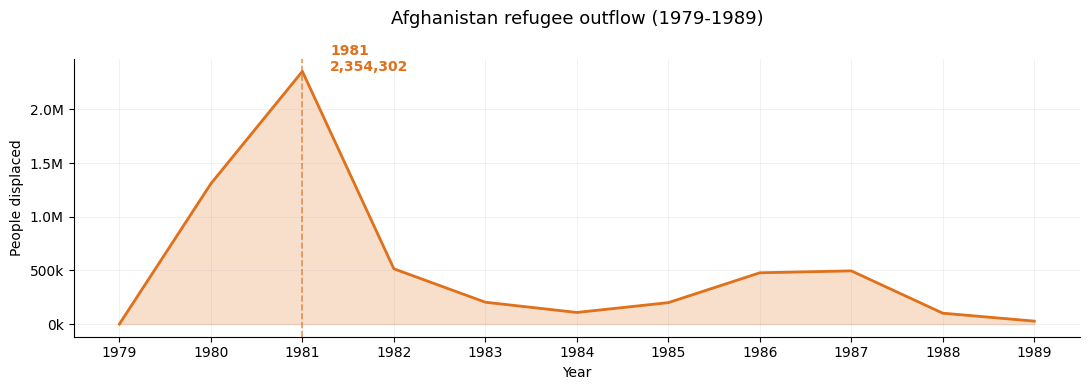

In [170]:
plot_annual_outflow(
    filtered_data,
    "afg",
    1979,
    1989,
    title="Afghanistan refugee outflow (1979-1989)",
    file_path="../visualizations/afghanistan_outflow.png",
    color="#e0701a",
    title_mode="ax",
    xticks=range(1979, 1990),
)
pass

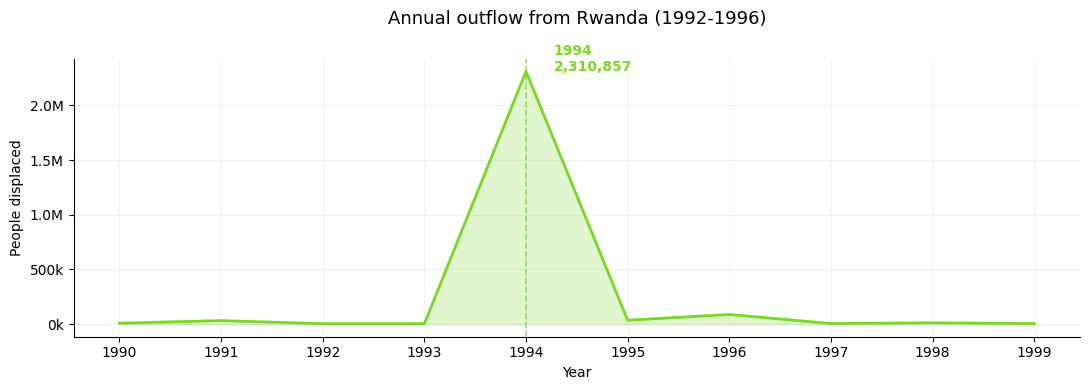

In [171]:
plot_annual_outflow(
    filtered_data,
    "rwa",
    1990,
    1999,
    title="Annual outflow from Rwanda (1992-1996)",
    file_path="../visualizations/rwanda_outflow.png",
    color="#7ad723",
    title_mode="ax",
    xticks=range(1990, 2000),
)
pass

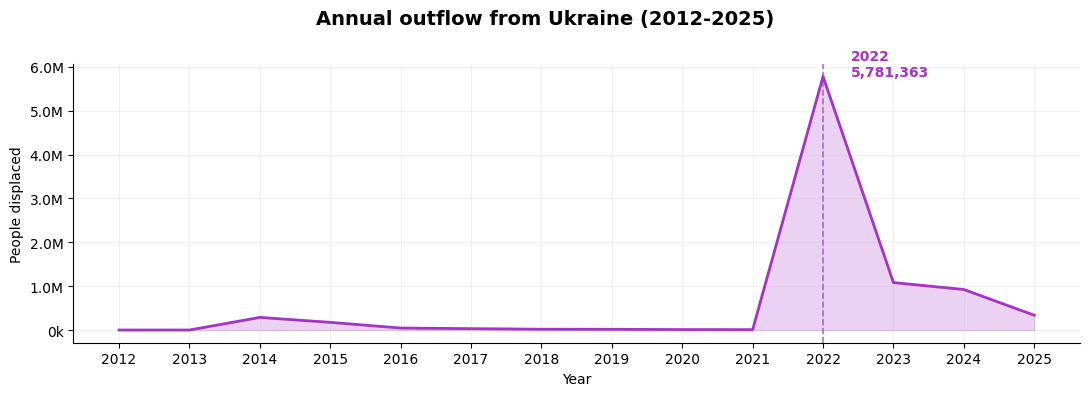

In [172]:
plot_annual_outflow(
    filtered_data,
    "ukr",
    2012,
    2025,
    title="Annual outflow from Ukraine (2012-2025)",
    file_path="../visualizations/ukraine_outflow_2012_2025.png",
    color="#a434c6",
    xticks=range(2012, 2026),
)
pass

In [173]:
# -------------------------------------------------
#        Nunmber of refugees VS distance
# -------------------------------------------------

# Prep plot data
# ------------------

afg_plot = (
    afg_sub
    .groupby(["asylumiso", "asylumname"], as_index=False)["count"]
    .sum()
)

afg_plot["border_distance_km"] = afg_plot.apply(
    lambda row: distance_to_country_border_km(
        "afg",
        row["asylumiso"],
        countries_gdf
    ),
    axis=1
)


# legend labels
# ----------------
afg_plot["legend_label"] = (
    afg_plot["asylumiso"].str.lower()
    + " — "
    + afg_plot["asylumname"].str.lower()
)

legend_order = sorted(afg_plot["legend_label"].unique())

# custom colors
# ----------------
color_discrete_map={
"pak — pakistan": "#28035e",
"irn — iran": "#9E84FA",
"deu — germany": "#a855f7",
"usa — united States": "#c084fc",
"sau — saudi Arabia": "#d8b4fe",
"ind — india": "#fcabcf",
}

def lighten_color(color, amount=0.85):
    """
    Lightens the given color.
    amount=0 -> original color
    amount=1 -> white
    """
    try:
        c = mc.cnames[color]
    except:
        c = color

    r, g, b = mc.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = 1 - amount * (1 - l)

    r, g, b = colorsys.hls_to_rgb(h, l, s)

    return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"



#       plot
# ------------------
fig = px.scatter(
    afg_plot,
    x="border_distance_km",
    y="count",
    size="count",

    # use combined legend labels
    color="legend_label",
    color_discrete_map=color_discrete_map,
    category_orders={
    "legend_label": legend_order
    },

    text="asylumiso",
    log_y=True,
    hover_name="asylumname",
    hover_data={
    "legend_label": False,
    "asylumiso": False,
    },

    labels={
        "border_distance_km": "Distance to border (km)",
        "count": "Number of Afghan refugees",
        "legend_label": "Destination country",
    },

    title="From Afghanistan to imigration country border - by distance and flow size (1980-1983)",
    # Destinations by distance from central Afghanistan to immigration country border (1980-1983)
    # Afghanistan to imigration country border - by distanve and flow size (1980-1983)
    # Distance to recieving country border


    # colors
    color_discrete_sequence=px.colors.sequential.Viridis,
)

    # Other color codes
    # -------------------------------------------------------------
    # blue
    # color_discrete_sequence=px.colors.sequential.Blues,
    # Viridis
    # color_discrete_sequence=px.colors.sequential.Viridis,
    # pastelle
    # olor_discrete_sequence=px.colors.qualitative.Set3
    # reds yellow
    # color_discrete_sequence=px.colors.sequential.YlOrRd


# put iran trace last so it is drawn on top
fig.data = tuple(
    [trace for trace in fig.data if not trace.name.startswith("irn")]
    + [trace for trace in fig.data if trace.name.startswith("irn")]
)

# circle size and style
# -----------------------
fig.update_traces(
    textposition="top center",
    marker=dict(
        sizemode="area",
        sizeref=40,   # smaller = larger bubbles
        opacity=0.8,
    )
)


# pastel hover / explainer box
# ------------------------------
for trace in fig.data:

    original_color = trace.marker.color

    trace.hoverlabel = dict(
        bgcolor=lighten_color(original_color, 0.35),
        font_size=13,
        font_color="black",
        bordercolor=original_color,
    )


# y axis
# ----------
fig.update_yaxes(
    range=[2, 7],   # 10^2 to 10^7
    tickvals=[1e2, 1e3, 1e4, 1e5, 1e6],
    ticktext=["100", "1k", "10k", "100k", "1M"],
)

# x axis
# ----------
fig.update_xaxes(
    tickvals=[0, 1000, 2000, 3000, 4000, 5000],
    ticktext=["0", "1000", "2000", "3000", "4000", "5000"],
)

fig.update_layout(
    title_x=0.5,
    width=1200,
    height=600,

    plot_bgcolor="#eeeeee",
    paper_bgcolor="white",

    font=dict(family="Helvetica", size=13),

    margin=dict(
        l=120,   # left
        r=260,   # right
        t=100,   # top
        b=100,   # bottom
    )
)

# helper lines
#-------------------------------------------
x_min = -1000
x_max = 5300

fig.update_xaxes(
    range=[x_min, x_max],
    tickvals=[0, 1000, 2000, 3000, 4000, 5000],
    ticktext=["0", "1000", "2000", "3000", "4000", "5000"],
)

for _, row in afg_plot.iterrows():

    x = row["border_distance_km"]
    y = row["count"]
    color = "#B8B8B8"

    fig.add_shape(
        type="line",
        x0=x_min,
        x1=x,
        y0=y,
        y1=y,
        xref="x",
        yref="y",
        line=dict(color=color, width=1, dash="dot"),
        layer="above",
    )

    fig.add_shape(
        type="line",
        x0=x,
        x1=x,
        y0=100,
        y1=y,
        xref="x",
        yref="y",
        line=dict(color=color, width=1, dash="dot"),
        layer="above",
    )

# save plot
fig.write_html("../visualizations/afghanistan_distance_vs_count.html")

fig.show()

In [176]:
# -------------------------------------------------
#     Number of refugees VS distance
#                1994-1996
# -------------------------------------------------

rwa_sub = filtered_data[
    (filtered_data["originiso"] == "rwa")
    & (filtered_data["year"].between(1994, 1996))
].copy()

rwanda_plot = (
    rwa_sub
    .groupby(["asylumiso", "asylumname"], as_index=False)["count"]
    .sum()
)

rwanda_plot["border_distance_km"] = rwanda_plot.apply(
    lambda row: distance_to_country_border_km(
        "rwa",
        row["asylumiso"],
        countries_gdf
    ),
    axis=1
)

# legend labels
# ----------------
rwanda_plot["legend_label"] = (
    rwanda_plot["asylumiso"].str.lower()
    + " — "
    + rwanda_plot["asylumname"].str.lower()
)

legend_order = sorted(rwanda_plot["legend_label"].unique())

# plot
# ------------------
fig = px.scatter(
    rwanda_plot,
    x="border_distance_km",
    y="count",
    size="count",

    color="legend_label",

    # pastelle
    # olor_discrete_sequence=px.colors.qualitative.Set3

    # reds yellow
    # color_discrete_sequence=px.colors.sequential.YlOrRd

    category_orders={
        "legend_label": legend_order
    },

    hover_data={
        "legend_label": False,
        "asylumiso": False,
    },

    # text="asylumiso",

    log_y=True,
    hover_name="asylumname",

    labels={
        "border_distance_km": "Distance to border (km)",
        "count": "Number of Rwanda refugees",
        "legend_label": "Destination country",
    },

    title="From Rwanda to imigration country border - by distance and flow size (1994-1996)",

    color_discrete_sequence=px.colors.sequential.Viridis,
)

# pastel hover labels
# -----------------------
for trace in fig.data:

    original_color = trace.marker.color

    trace.hoverlabel = dict(
        bgcolor=lighten_color(original_color, 0.65),
        font_size=13,
        font_color="black",
        bordercolor=original_color,
    )

# put Burundi and Tanzania on top
fig.data = tuple(
    [trace for trace in fig.data
     if not (
         trace.name.startswith("bdi")
         or trace.name.startswith("tza")
     )]
    +
    [trace for trace in fig.data
     if trace.name.startswith("tza")]
    +
    [trace for trace in fig.data
     if trace.name.startswith("bdi")]
)

# circle size and style
# -----------------------
fig.update_traces(
    textposition="top center",
    marker=dict(
        sizemode="area",
        sizeref=15,
        opacity=0.6,
    )
)

# y axis
# ----------
fig.update_yaxes(
    range=[2, 7],
    tickvals=[1e2, 1e3, 1e4, 1e5, 1e6],
    ticktext=["100", "1k", "10k", "100k", "1M"],
)

# x axis
# ----------
x_min = -1000
x_max = 6500

fig.update_xaxes(
    range=[x_min, x_max],
    tickvals=[0, 1000, 2000, 3000, 4000, 5000, 6000],
    ticktext=["0", "1000", "2000", "3000", "4000", "5000", "6000"],
)

fig.update_layout(
    title_x=0.5,
    width=1200,
    height=600,

    plot_bgcolor="#f0f0f0",
    paper_bgcolor="white",

    font=dict(family="Helvetica", size=13),

    margin=dict(
        l=120,
        r=100,
        t=100,
        b=100,
    )
)

# helper lines
# -------------------------------------------
for _, row in rwanda_plot.iterrows():

    x = row["border_distance_km"]
    y = row["count"]
    color = "#B8B8B8"

    fig.add_shape(
        type="line",
        x0=x_min,
        x1=x,
        y0=y,
        y1=y,
        xref="x",
        yref="y",
        line=dict(color=color, width=1, dash="dot"),
        layer="above",
    )

    fig.add_shape(
        type="line",
        x0=x,
        x1=x,
        y0=100,
        y1=y,
        xref="x",
        yref="y",
        line=dict(color=color, width=1, dash="dot"),
        layer="above",
    )

# save and show
fig.write_html("../visualizations/rwanda_distance_vs_count.html")

fig.show()

In [177]:
# -------------------------------------------------
#        Ukraine war: refugees VS distance
#        2022-2024
# -------------------------------------------------

ukr_sub = filtered_data[
    (filtered_data["originiso"] == "ukr")
    & (filtered_data["year"].between(2022, 2024))
].copy()

ukraine_plot = (
    ukr_sub
    .groupby(["asylumiso", "asylumname"], as_index=False)["count"]
    .sum()
)

# keep only destinations with 1000+ refugees
ukraine_plot = ukraine_plot[
    ukraine_plot["count"] >= 1000
].copy()

ukraine_plot["border_distance_km"] = ukraine_plot.apply(
    lambda row: distance_to_country_border_km(
        "ukr",
        row["asylumiso"],
        countries_gdf
    ),
    axis=1
)

# custom colors
def lighten_color(color, amount=0.35):
    r, g, b = pc.hex_to_rgb(color)

    r = int(r + (255 - r) * amount)
    g = int(g + (255 - g) * amount)
    b = int(b + (255 - b) * amount)

    return f"rgb({r},{g},{b})"

# legend labels
# ----------------
ukraine_plot["legend_label"] = (
    ukraine_plot["asylumiso"].str.lower()
    + " — "
    + ukraine_plot["asylumname"].str.lower()
)

legend_order = sorted(ukraine_plot["legend_label"].unique())

# plot
# ------------------
fig = px.scatter(
    ukraine_plot,
    x="border_distance_km",
    y="count",
    size="count",

    log_x=True,
    log_y=True,

    color="legend_label",

    hover_data={
    "legend_label": False,
    "asylumiso": False,
    },

    category_orders={
        "legend_label": legend_order
    },

    text="asylumiso",
    hover_name="asylumname",

    labels={
        "border_distance_km": "Distance to destination border (km) - log scale",
        "count": "Number of Ukrainian refugees - log scale",
        "legend_label": "Destination country (log scale)",
    },

    title="From Ukraine to imigration country border - by distance and flow size (2022-2024)",
    
    color_discrete_sequence=px.colors.sequential.Viridis,
)

# put major nearby destinations on top
fig.data = tuple(
    [trace for trace in fig.data
     if not (
         trace.name.startswith("pol")
         or trace.name.startswith("deu")
         or trace.name.startswith("cze")
     )]
    +
    [trace for trace in fig.data
     if trace.name.startswith("cze")]
    +
    [trace for trace in fig.data
     if trace.name.startswith("deu")]
    +
    [trace for trace in fig.data
     if trace.name.startswith("pol")]
)

# circle size and style
# -----------------------
fig.update_traces(
    textposition="top center",
    marker=dict(
        sizemode="area",
        sizeref=120,
        opacity=0.7,
    )
)

# pastel hover / explainer box
# ------------------------------
for trace in fig.data:

    original_color = trace.marker.color

    trace.hoverlabel = dict(
        bgcolor=lighten_color(original_color, 0.65),
        font_size=13,
        font_color="black",
        bordercolor=original_color,
    )

# y axis
# ----------
# fig.update_yaxes(
#     range=[3, 7],   # 10^3 to 10^7
#     tickvals=[1e3, 1e4, 1e5, 1e6],
#     ticktext=["1k", "10k", "100k", "1M"],
# )

fig.update_yaxes(
    tickvals=[5e3, 1e4, 5e4, 1e5, 3e5, 5e5, 7e5, 1e6, 1.5e6, 2.e6],
    ticktext=["5K", "10K", "50K", "100K", "300K", "500K", "700K", "1M", "1.5M", "2M"],
)

# x axis
# ----------
x_min = 1
x_max = 5000

fig.update_xaxes(
    range=[math.log10(250), 4],
    tickvals=[250, 500, 1000, 2000, 5000],
    ticktext=["250", "500", "1000", "2000", "5000"],
)

fig.update_layout(
    title_x=0.5,
    width=1200,
    height=900,

    plot_bgcolor="#f0f0f0",
    paper_bgcolor="white",

    font=dict(family="Helvetica", size=13),

    margin=dict(
        l=120,
        r=260,
        t=100,
        b=100,
    )
)

# helper lines
#-------------------------------------------
reference_lines = [
    (5_000, "5K"),
    (10_000, "10K"),
    (50_000, "50K"),
    (100_000, "100K"),
    (300_000, "300K"),
    (500_000, "500K"),
    (700_000, "700K"),
    (1_000_000, "1M"),
    (1_500_000, "1.5M"),
    (2_000_000, "2M"),
]

for y_value, label in reference_lines:
    fig.add_hline(
        y=y_value,
        line_width=1,
        line_dash="dot",
        line_color="#BDBDBD",
        annotation_text=label,
        annotation_position="left",
        annotation_font_size=11,
        annotation_font_color="#555555",
    )

# Extravscatter for readibility
# -----------------------------------
# center dots 
for trace in fig.data:

    try:
        y = trace.y[0]
    except:
        continue

    if y > 50_000:

        fig.add_scatter(
            x=trace.x,
            y=trace.y,

            mode="markers",

            marker=dict(
                size=6,
                color=trace.marker.color,
            ),

            showlegend=False,
            hoverinfo="skip",
        )

# save and show
fig.write_html("../visualizations/ukraine_distance_vs_count.html")

fig.show()

# 5 - A focus on three conflicts

From our mapped data, we notice the main crisis and spikes of large displacements indark red. For our story we wanted to have a look at "Where people go?". If forced to flee, how far do people travel? With a focus on distances, can we find patterns of behaviour? is proximity a factor in displacements? Or do people prefer fleeing FAR away from war, genocide, and other horrors? As it gets easier and easier to fly across the world, do those patterns change over time? Do people tend to move further away as time goes by?

We decided to have a deep dive at three of the most important crisis our data has to offer. For comparability, we made sure to pick crises that occur in different decades, so we can spot potential changes of behaviour over time.



## 5.1 Soviet-Afghan War (Dec 1979 - Feb 1989)

Though the war lasted a decade (and more), our data shows a high peak of displacements from 1980 to 1983 in particular. This leads us to believe the flow of forced displaced people is highter at the beginning of a crisis. let's go ahead and plot that to see what it looks like.


Note on Afghanistan: the intensity and length of thos conflict makes Afghanistan somewhat of an outlier in this analysis.

Though the conflict officially end in 1989, the instability persisted long afterward as the Taliban continued to control large parts of the country until the U.S. invasion in 2001. These decades of sustained instability produced one of the world’s largest and most prolonged refugee crises.
source: UNHCR - https://www.unhcr.org/where-we-work/countries/afghanistan?utm_source=chatgpt.com&dataset=POP&yearsMode=range&selectedYears=%5B2012%2C2026%5D&level=OPR&category=PTY&fundingSource=ALS&compareBy=%5B%22category%22%5D&levelCompare=%5B%5B%22OAFG_ABC%22%5D%5D&viewType=chart&chartType=bar&contextualDataset=BUD&tableDataView=absolute


"In fact, Afghanistan has experienced one of the world's largest refugee crises for more than two decades. Between the Soviet invasion of Afghanistan in 1979 and the present day, **one in four Afghans has been a refugee**. At the peak of the crisis in the late 1980s, there were more than six million Afghan refugees. "
source: The Forced Migration Review - https://www.fmreview.org/ruiz/

The soviets started their occupation (between 1980 - 1085) with a "scorched earth campaign", which aimed to cut any support the mujahideen (religious Afghan freedom fighters) might have in the region. This implied the destrucyion of crops, irrication systems, and villages and affected local population terribly. By the end of 1981, the widespread destruction of civilian infrastructure further intensified displacement and cross-border asylum movements.

Source: This article written my HIstory professor Edward B. Westermann
https://journals.lib.unb.ca/index.php/jcs/article/view/4356/5011

"Soviet attempts to intimidate the civil population involved a joint air-land effort. The intensive bombardment of villages [...] erved as the prelude for the entry of mechanized and armored forces into the area. These forces then proceeded to conduct a "scorched earth" campaign by destroying the local dwellings, food supplies, crops in the field, irrigation systems, livestock and wells. One Swedish official, after visiting several villages destroyed by the Soviets noted, "Russian soldiers shot at anything alive in six villages -- people, hens, donkeys - and then they plundered what remained of value."16 These Soviet operations aimed at driving the villagers out of these areas in an effort to create a cordon sanitaire in which the insurgents would find no support.

In [ ]:
# ---------------------------------------------------------
#      Afghan refugee destinations by year (1980–1988)
# ---------------------------------------------------------

table = (
    filtered_data[
        (filtered_data["originiso"] == "afg") &
        (filtered_data["year"].between(1980, 1988))
    ]
    .groupby(["asylumname", "year"])["count"]
    .sum()
    .unstack(fill_value=0)
)

# sort by total refugees received
table = table.loc[
    table.sum(axis=1).sort_values(ascending=False).index
]

# format numbers nicely
def pretty(x):

    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"

    elif x >= 1_000:
        return f"{x/1_000:.0f}k"

    return str(int(x))

table_display = table.map(pretty)

table_display

### For our story - where do people go?

- We immediately notice Iran in dark red taking in a whooping 1.4 million people in 1981, followed closely by Pakistan with close to a million refugees. those are two adjascent countries.

- But what about the other adjacent countries north of the country: Turkmenistan, Uzbekistan, and Tajikistan? Why are they marked in grey? Did they not take in any refugees? ...Not quite.
You may remember at the beginning of the analysis that we mentioned the maps did not take into consideration the creation of new countries over time. A Folium map usually uses current country borders, because it relies on modern basemap tiles or modern GeoJSON/shapefiles. Back in 1980 ,The three aforementioned countries were still part of the USSR bloc and therefore were considered part of the direct attacking force, explaining more clearly why no Afghan would seek refuge up north.

- Iran from 1.4M in 1981 to 0 in 1982?
Why do some countries take in massive numbers one year and then 0 the following year? Iran 1.4M in 1981 and then 0 in 1982? Policy changes? Did the borders suddenly close? Two things:
    - **Status name:** Upon closer inspection, it would rather seem that this is more a question of “status” than an actual halt in displacement flows. Though the borders were indeed opnened during this period, displaced people were not labeled as "refugees" and could therefore be unregisttered in our UNHCR dataset. So our data may show 0 while in reality hundreds were still physically crossing into Iran.

    - **UNHCR reconstruction of numbers retrospectively:** It may have been hard to keep track of the exact flux taking place each year of the conflict, and it could be that some records were incomplete, estimated retrospectively, or merged into a single year. This is something that can occur with older displacement data. We therefore suspect that something may have gone wrong in the way the data was recorded or reconstructed, especially since we know for a fact that the borders remained open during this period.

"Until 1992, the Iranian government allowed many Afghans to register as “involuntary migrants” (mohajerin), gain automaticresidency in Iran, and enjoy benefits such as basic healthcare and work permits. Iranian officials effectively treated these registered Afghans as refugees, though that designation was not officially used by the Iranian government"
Source: Human Rights Watch
https://www.hrw.org/reports/iran1113_ForUpload_0.pdf?utm_source=chatgpt.com


- As seen in our preliminary study, we have few data points around this decade. (backs up the abovementioned)


### How far do people go?

let's have a closer look at the average distance traveled by refugees to flea this conflict:

In [ ]:
# -------------------------------------------------
#  Average distance traveled by Afghan refugees
# -------------------------------------------------

#   weighted sum: distance * num_refugees / total_refugees
#   between 1980 -1983
#   distance = centroid of Afghanistan to nearest border point of destination country

# filter area of focus
afg_sub = filtered_data[
    (filtered_data["originiso"] == "afg")
    & (filtered_data["year"].between(1980, 1983))
].copy()

# compute total refugees leaving Afghanistan in this period
total_refugees = afg_sub["count"].sum()

# compute weighted distance a refugee has to travel to reach a new border
def weighted_distance(row):
    border_distance = distance_to_country_border_km(
        row["originiso"],
        row["asylumiso"],
        countries_gdf
    )
    return (border_distance * row["count"]) / total_refugees

afg_sub["weighted_distance_km"] = afg_sub.apply(weighted_distance, axis=1)
print()
print("Estimated average distance traveled by refugees from central Afghanistan \nto the destination country's border, weighted by Afghan refugee counts, 1980-1983:")
print(round(afg_sub["weighted_distance_km"].sum(), 2), "km")


In [ ]:
afg_plot.sort_values("count")

Not all host countries figure on th eplot as they would be too small to show.

This bubble plot shows refugee flows in relation to the distance to the host country. Once again we clearly see the massive amount of displaced moving towards Iran and Pakistan, as they are neighboring countries and easiest to access, both from a geography point of vew but also from an immigration policy oour ov view. As we saw earlier Iran kept it's doors open to refuegees and asylum seekers durng the Soviet-Afghan conflict.
Source: Human Rights Watch
https://www.hrw.org/reports/iran1113_ForUpload_0.pdf?utm_source=chatgpt.com

Though India is relatively close, located just "behind" Pakistan, it took relativeæy few refugees: 7870.

Similar observation for the United Arab Emirates Saudi Arabia, located "behind" Iran, who only took respectively 1.500 and 2000 refugees.
A small potion of the 4 Million forced displacements observed between 1979 amd 1983

## 5.2 - A focus on the Rwanda Genocide (1994 -1996)

In [ ]:
# -------------------------------------------------
#      A fitrst look at the numbers of refugees
# -------------------------------------------------

# total  refugees leaving Rwanda between 1990 and 1994
total_rwa_refugees_1990_1994 = (
    filtered_data[
        (filtered_data["originiso"] == "rwa")  & (filtered_data["year"].between(1990, 1994))
    ]["count"]
    .sum()
)
print(f"Total refugees leaving Rwanda from 1990 to 1994: {total_rwa_refugees_1990_1994:,}")

### How far do people go?

let's have a closer look at the average distance traveled by refugees to flea this conflict:

In [ ]:
# -------------------------------------------------
#  Average distance traveled by Rwandan refugees
# -------------------------------------------------

#   weighted sum: distance * num_refugees / total_refugees
#   between 1994 - 1996
#   distance = centroid of Rwanda to nearest border point of destination country

# filter area of focus
rwa_sub = filtered_data[
    (filtered_data["originiso"] == "rwa")
    & (filtered_data["year"].between(1994, 1996))
].copy()

# compute total refugees leaving Rwanda in this period
total_refugees = rwa_sub["count"].sum()

# compute weighted distance a refugee has to travel to reach a new border
def weighted_distance(row):
    border_distance = distance_to_country_border_km(
        row["originiso"],
        row["asylumiso"],
        countries_gdf
    )
    return (border_distance * row["count"]) / total_refugees

rwa_sub["weighted_distance_km"] = rwa_sub.apply(weighted_distance, axis=1)

print()
print("Estimated average distance traveled by refugees from central Rwanda")
print("to the destination country's border, weighted by Rwandan refugee counts, 1994-1996:")
print(round(rwa_sub["weighted_distance_km"].sum(), 2), "km")

In [ ]:
rwanda_plot.sort_values("count")

## 5.3 - Russia's invation of Ukraine (2022 - 2025, when the data stops)

small intro

+ notes on invasion of Crimea in 2014

In [ ]:
# -------------------------------------------------
#      A fitrst look at the numbers of refugees
# -------------------------------------------------

# total count of refugees leaving Ukraine between 2013 and 2025
total_ukr_refugees_2013_2025 = (
    filtered_data[
        (filtered_data["originiso"] == "ukr")  & (filtered_data["year"].between(2013, 2025))
    ]["count"]
    .sum())
print(f"Total refugees leaving Ukraine from 2013 to 2025: {total_ukr_refugees_2013_2025:,}")

# Number of refugees leavig between 2012 and 2015
total_ukr_refugees_2012_2015 = (
    filtered_data[
        (filtered_data["originiso"] == "ukr")  & (filtered_data["year"].between(2012, 2015))
    ]["count"]
    .sum())
print(f"Total refugees leaving Ukraine from 2012 to 2015: {total_ukr_refugees_2012_2015:,}")

# number of refugees leaving between 2022 and 2025
total_ukr_refugees_2022_2025 = (
    filtered_data[
        (filtered_data["originiso"] == "ukr")  & (filtered_data["year"].between(2022, 2025))
    ]["count"]
    .sum())
print(f"Total refugees leaving Ukraine from 2022 to 2025: {total_ukr_refugees_2022_2025:,}")


### How far do people go?

In [174]:
# -------------------------------------------------
#  Average distance traveled by Ukrainian refugees
# -------------------------------------------------

#   weighted sum: distance * num_refugees / total_refugees
#   between 2022 - 2025
#   distance = centroid of Ukraine to nearest border point of destination country

# filter area of focus
ukr_sub = filtered_data[
    (filtered_data["originiso"] == "ukr")
    & (filtered_data["year"].between(2022, 2025))
].copy()

# compute total refugees leaving Ukraine in this period
total_refugees = ukr_sub["count"].sum()

# compute weighted distance a refugee has to travel to reach a new border
def weighted_distance(row):
    border_distance = distance_to_country_border_km(
        row["originiso"],
        row["asylumiso"],
        countries_gdf
    )
    return (border_distance * row["count"]) / total_refugees

ukr_sub["weighted_distance_km"] = ukr_sub.apply(weighted_distance, axis=1)

print()
print("Estimated average distance traveled by refugees from central Ukraine")
print("to the destination country's border, weighted by Ukrainian refugee counts, 2022-2025:")

print(round(ukr_sub["weighted_distance_km"].sum(), 2), "km")


Estimated average distance traveled by refugees from central Ukraine
to the destination country's border, weighted by Ukrainian refugee counts, 2022-2025:
1172.42 km


# 6 - Comparing the three crisis

In [ ]:
# Small multiples — outflow from each crisis country
CRISES = [
    ("afg", "Afghanistan", 1980, "#e0701a"),
    ("rwa", "Rwanda",      1994, "#7ad723"),
    ("ukr", "Ukraine",     2022, "#a434c6"),
]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, sharey=True)

for ax, (iso, name, _hint_peak, color) in zip(axes, CRISES):
    series = (
        filtered_data[filtered_data["originiso"] == iso]
        .groupby("year")["count"].sum()
        .reindex(range(1962, 2026), fill_value=0)
    )
    ax.fill_between(series.index, series.values, color=color, alpha=0.22)
    ax.plot(series.index, series.values, color=color, linewidth=2)

    # Auto-detect actual peak year from the data
    peak     = int(series.idxmax())
    peak_val = int(series.loc[peak])

    ax.axvline(peak, color=color, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.annotate(
        f"{peak}\n{int(peak_val):,}",
        xy=(peak, peak_val),
        xytext=(8, -8), textcoords="offset points",
        fontsize=10, fontweight="bold", color=color, va="top",
    )

    ax.set_title(f"{name} ({iso})", loc="left", fontsize=12, fontweight="bold", pad=4)
    ax.set_ylabel("People displaced")
    ax.grid(alpha=0.25)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f"{int(x/1e6)}M" if x >= 1e6 else f"{int(x/1e3)}k"
    ))

axes[-1].set_xlabel("Year")
fig.suptitle("Annual outflow from three crisis countries (shared Y-axis)",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
plt.savefig("../visualizations/crisis_outflows.png", dpi=150, bbox_inches="tight")
plt.show()


In [178]:
# Sankey — origin → top destinations, summed over the full crisis period
CRISES_SANKEY = [
    ("afg", "Afghanistan", 1979, 1990),
    ("rwa", "Rwanda",      1994, 1996),
    ("ukr", "Ukraine",     2022, 2025),
]
TOP_K = 10

for iso, name, y_start, y_end in CRISES_SANKEY:
    flows = (
        filtered_data[(filtered_data["originiso"] == iso) &
                      (filtered_data["year"] >= y_start) & (filtered_data["year"] <= y_end)]
        .groupby("asylumname", as_index=False)["count"].sum()
        .sort_values("count", ascending=False)
        .head(TOP_K)
    )

    if flows.empty:
        print(f"No data for {name} {y_start}-{y_end}")
        continue

    asylum_labels = flows["asylumname"].fillna("Unknown").tolist()
    values        = flows["count"].astype(int).tolist()
    total         = sum(values)
    period_label  = f"{y_start}\u2013{y_end}"

    labels = [f"{name}<br>{period_label}"] + asylum_labels
    source = [0] * len(asylum_labels)
    target = list(range(1, len(asylum_labels) + 1))

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=18, thickness=20,
            line=dict(color="black", width=0.4),
            label=labels,
            color=["#c0392b"] + ["#3498db"] * len(asylum_labels),
            hovertemplate="<b>%{label}</b><br>%{value:,} people<extra></extra>",
        ),
        link=dict(
            source=source, target=target, value=values,
            color="rgba(52, 152, 219, 0.4)",
            hovertemplate="<b>%{source.label} \u2192 %{target.label}</b><br>"
                          "%{value:,} people (cumulative)<extra></extra>",
        ),
    )])

    fig.update_layout(
        title=dict(
            text=f"<b>{name} {period_label}</b> \u2014 top {len(values)} destinations &nbsp;"
                 f"<span style='color:#7f8c8d;font-size:13px'>"
                 f"({total:,} people, cumulative across the period)</span>",
            x=0.02, xanchor="left",
        ),
        font=dict(size=13, family="Arial"),
        height=520,
        margin=dict(l=20, r=20, t=70, b=20),
        paper_bgcolor="white",
    )

    fig.write_html(f"../visualizations/sankey_{iso.lower()}_{y_start}_{y_end}.html")
    fig.show()


# Draft

In [ ]:
# -----------------------------------------------------------------
#                       Things to talk about ? 
# -----------------------------------------------------------------

"""

 EXPLORATION OF THE DATA 
            <br>
            whata re the top 3 events in our data that caused the largest displacements?
            <br>
            (this is a good spot for Loke's chart).
            0 - filtering: only keep "significant" displacements, removeless than 100 people entries +  displacement from 10.000 people per year = min threshold, 
            or use median if number of displaced is larger than 10K
            <br>
            2 - in sheer numbers ...what are the largest displacements recorded in our data 
            3 - taking into consideration the length of the conflict/crisis. 1 million people moving over 20 years doesn't have the same impart as 
            1 million people moving over 1 year. so we can compute a "ratio" of "total displaced" VS "annual displaced"
            <img src="TishDuc.github.io/Displacements_Final_Project/Draft/Top_10.png"/>
            <p class="caption">
            Top 10 events in the modern era that caused the largest displacements. Computed taking into consideration the length of the crisis, 
            to show the "intensity" of the displacements.
            </p>
            <br>
            OUR DATA: UNHCR data on displacements around the world, from 1962 to 2025 + other data GDP? country population (to compute ratios)? 
        </p>
        </section>


        </section>
        <section class = "text"></section>

        DRAFT OF THE STORY:
            <br>
            <br>
            - Ratio thing: Natural disasters/conflicts/war have different lengths. find a way to express the "amount" of displcement 
            taking that into consideration. 1 million people moving over 20 years doesn't have the same impart as 
            1 million people moving over 1 year. 
            Total displaced VS annual displaced
            <br>
            <br>
            - Filtering the data: 
            crisis = 10.000 peple displaced in 1 year - OR - use a "percentage/median" of the total population of the country (example of Afghanistan)
            removed "tiny" values, only kept movements of more than 100 people 
            <br>
            <br>
            - Sometimes, lots of poeple move from A to B (single country), other times people move from B to B, C, D,..(several countries)
            why? is this something to look into?
            <br>
            <br>
            - Early data: Some large conflicts from the 70's80's (Afganistan/Ethiopia) make it in out "Top" 20 in sheer number of displaced.
            Yet data of that period is so sparce/so rare at the time. Does that mean that the actual number of displaced was HUUUUUGE?
            <br>
            <br>
            - Displacements types: Asylum seekers, refugees....
            Do we look into the different status of displaced people? 
            <br>
            <br>
            - Suspiciously round numbers: in the data ... were there exactly 20,000 people moving from Angola to Congo in 1962?
            looks suspicious to me?
            <br>
            <br>
            - Why do they "choose" the country the go to? 
            is it because of language? culture/religoin? proximity? economic opportunities? easier migration policies?
            <br>
            <br>
            LIMITS OF OUR DATASET: 
            <br>
            <br>
            - Only tracks INTERNATIONAL movements... so it' snot adequate for "natural disasters", or local population movements
            not adequete for tsunami in 2006 in indonesia: too many different countries around the Indian Ocean.
            partly Adequate for Tchernobyl in 1986?...ish (people moving from Ukraine to Russia)? but not tracting russian people moving elsewhere to Russia.
            <br>
            <br>
            - Displacements are recorded per year: so we can-t look at the "immediate" impact of a crisis, but rather the "long-term" impact. 
            and we can't look at super short yet intense crisis.
            <br>
            <br>
            limited data from 1960 to ...1990...2000
            <br>
            <br>
            Keeping in mind the numbers we have are only the "ocfficially" recorded displacements... there are probably many more.
            <br>
            <br>
            - "unknown" or "stateless" displacements: 
            Do we count "unkown" as missing data?
            Or are they called "unknown" because origin countries were renamed/created/disappeared OR are those the precisely 
            the "stateless" entries? foe example we soo lots of "stateless" displacements entering Europe in 1989... ex-Yougoslavia?
            In some cases (Uganda) it be that people they wish to remain unknown for their own safety...for political/ethnicity/religious reasons 
         
            

"""